In [1]:
# Nettoyage complet
print("Nettoyage...")
%reset -f
%whos

Nettoyage...
Interactive namespace is empty.


In [27]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
import os
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from joblib import Parallel, delayed
from matplotlib.colors import LogNorm
from matplotlib.colors import PowerNorm

In [3]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

In [4]:
requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
"""

requete_lots_infos_basiques = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    l.lot_date_creation,
    l.lot_date_archive,
    l.lot_surface,
    l.lot_batiment,
    l.etage_id,
    l.adresse_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
"""

In [5]:
lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)
print(lots_adresses.columns)

lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)
print(lots_infos_basiques.columns)

C:\Users\quent\AppData\Local\Temp\ipykernel_7404\97871670.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)


Index(['lot_id', 'lot_actif', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_7404\97871670.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)


Index(['lot_id', 'lot_actif', 'lot_date_creation', 'lot_date_archive',
       'lot_surface', 'lot_batiment', 'etage_id', 'adresse_id'],
      dtype='object')


In [6]:
conn.commit()
cursor.close()
conn.close()

In [7]:
gdf_offres = gpd.GeoDataFrame(lots_adresses, geometry=gpd.points_from_xy(lots_adresses.adr_plan_x, lots_adresses.adr_plan_y), crs="EPSG:4326")

# Reprojeter en Web Mercator 
gdf_offres = gdf_offres.to_crs(epsg=3857)

print(gdf_offres.shape)

(2422093, 11)


In [8]:
del lots_adresses

gc.collect()

0

In [9]:
# Supprimer la colonne si elle existe déjà
if 'lot_actif' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif', inplace=True)
if 'lot_actif_x' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_x', inplace=True)
if 'lot_actif_y' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_y', inplace=True)

In [10]:
lots_actifs = lots_infos_basiques.groupby('lot_id', as_index=False)['lot_actif'].max()
gdf_offres = gdf_offres.merge(lots_actifs, on='lot_id', how='left')

# Filtrage : uniquement les points actifs
gdf_offres = gdf_offres[gdf_offres['lot_actif'] == 1]

gdf_offres = gdf_offres.to_crs(epsg=3857)

In [11]:
del lots_actifs
del lots_infos_basiques 
gc.collect()

0

In [12]:
# On ne garde que ce qui est en France
gdf_offres = gdf_offres.cx[-560000:1200000, 5000000:6700000]

# Vérifier les min/max
print(gdf_offres['adr_plan_x'].min(), gdf_offres['adr_plan_x'].max())
print(gdf_offres['adr_plan_y'].min(), gdf_offres['adr_plan_y'].max())

# Vérifier les valeurs manquantes
print(gdf_offres[['adr_plan_x', 'adr_plan_y']].isnull().sum())

-4.77380330000005 9.448236465454102
41.39147524875518 51.2312752
adr_plan_x    0
adr_plan_y    0
dtype: int64


Traitement de la région : Île-de-France (11)


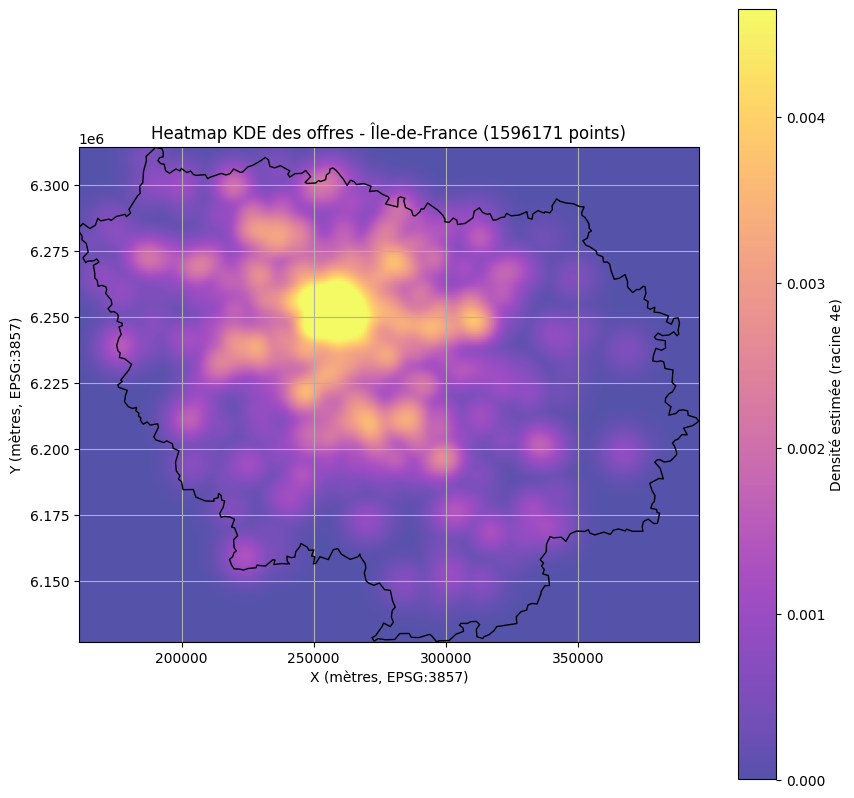

Traitement de la région : Centre-Val de Loire (24)


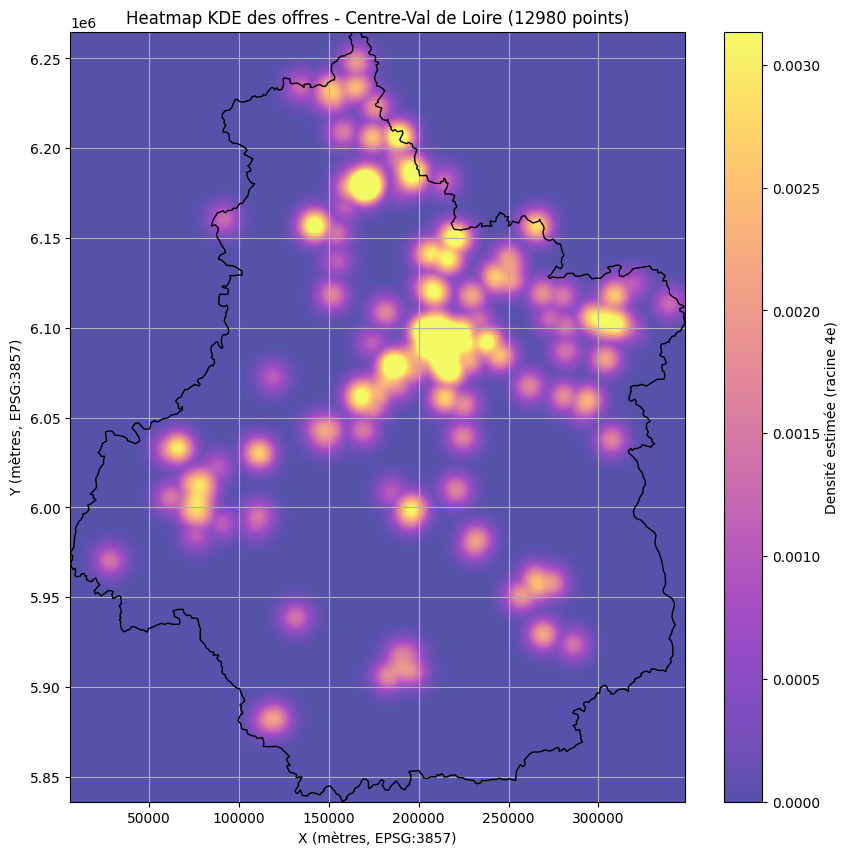

Traitement de la région : Bourgogne-Franche-Comté (27)


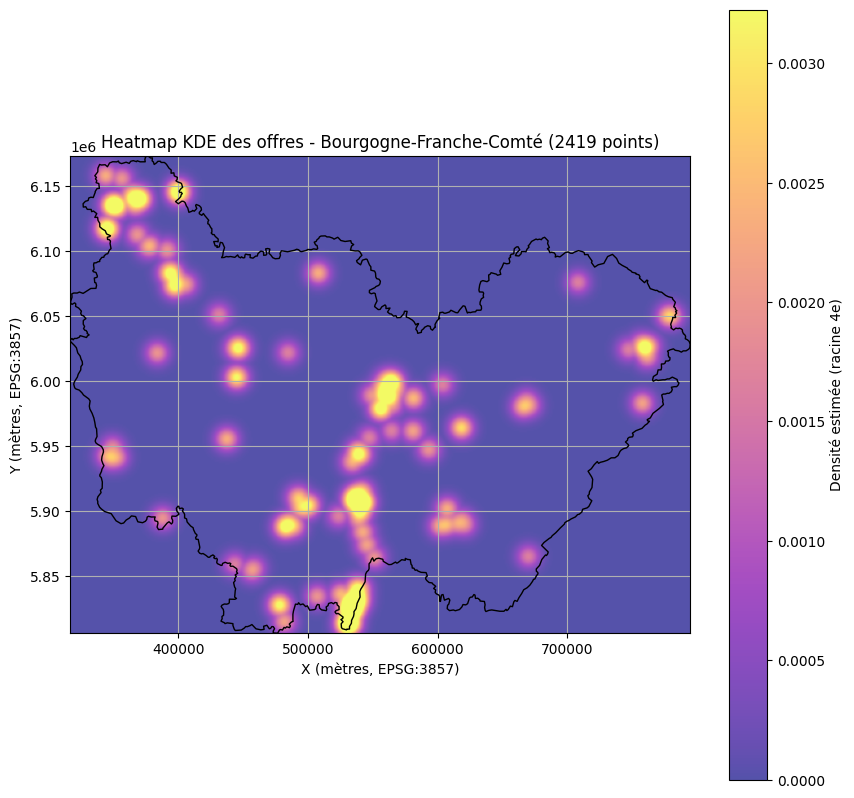

Traitement de la région : Normandie (28)


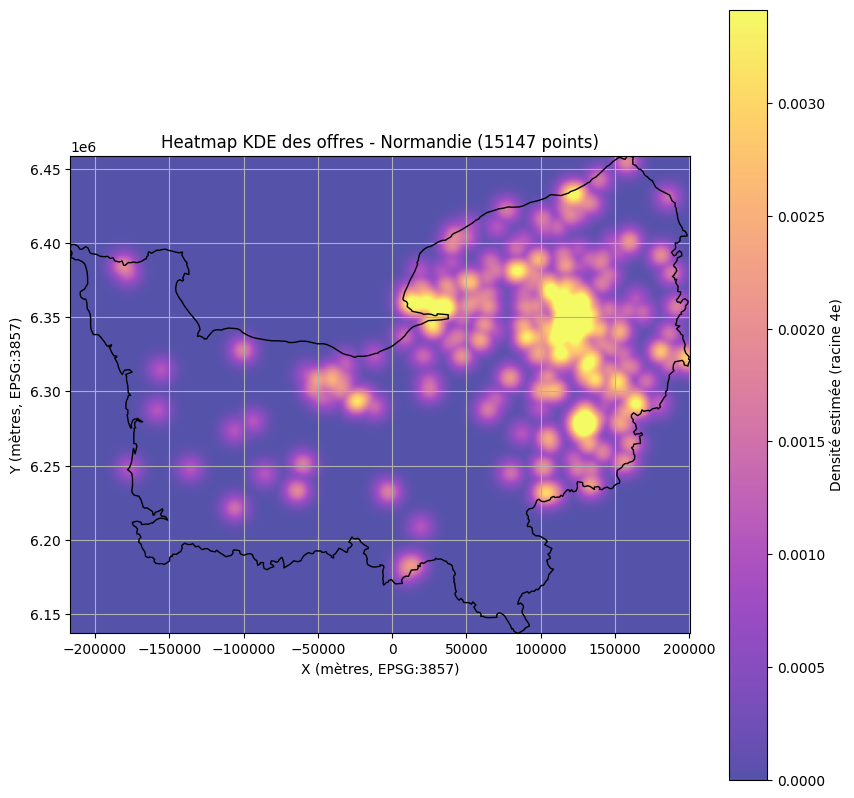

Traitement de la région : Hauts-de-France (32)


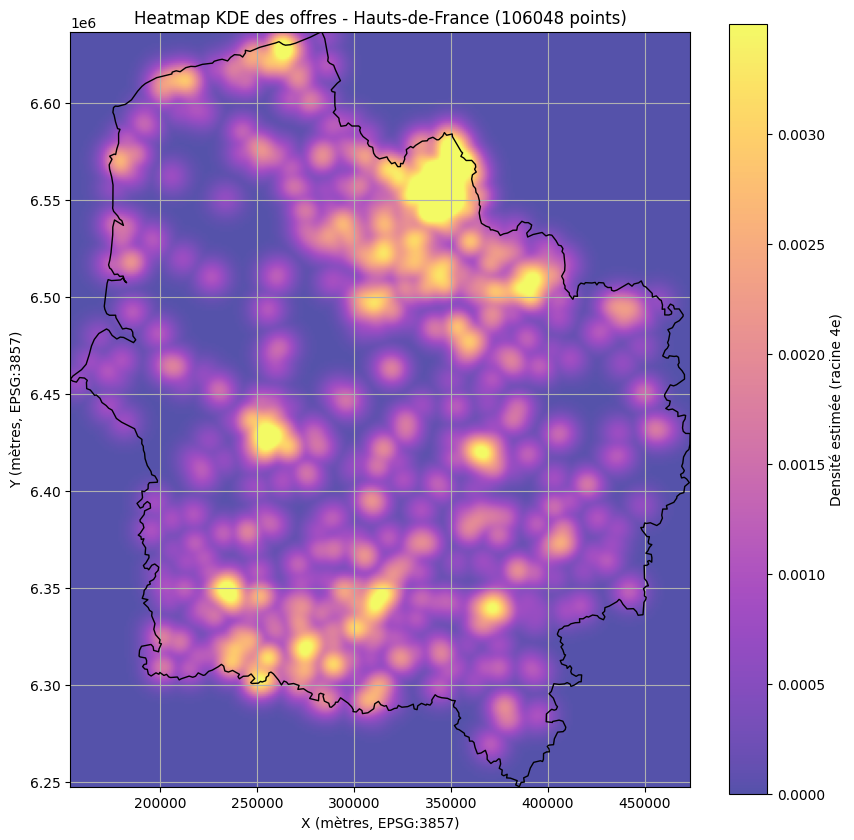

Traitement de la région : Grand Est (44)


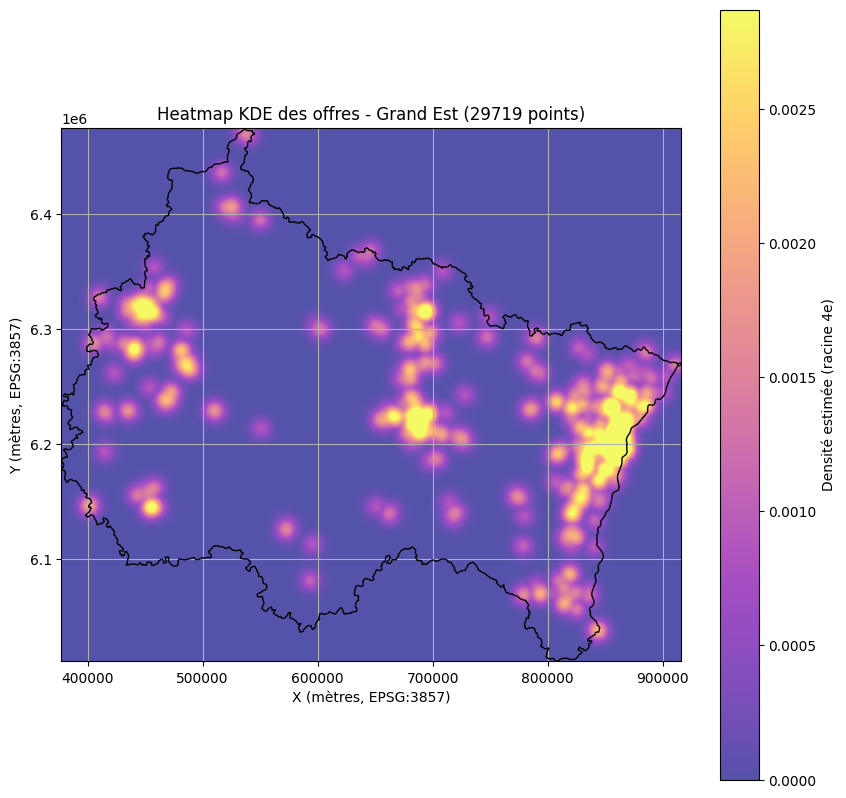

Traitement de la région : Pays de la Loire (52)


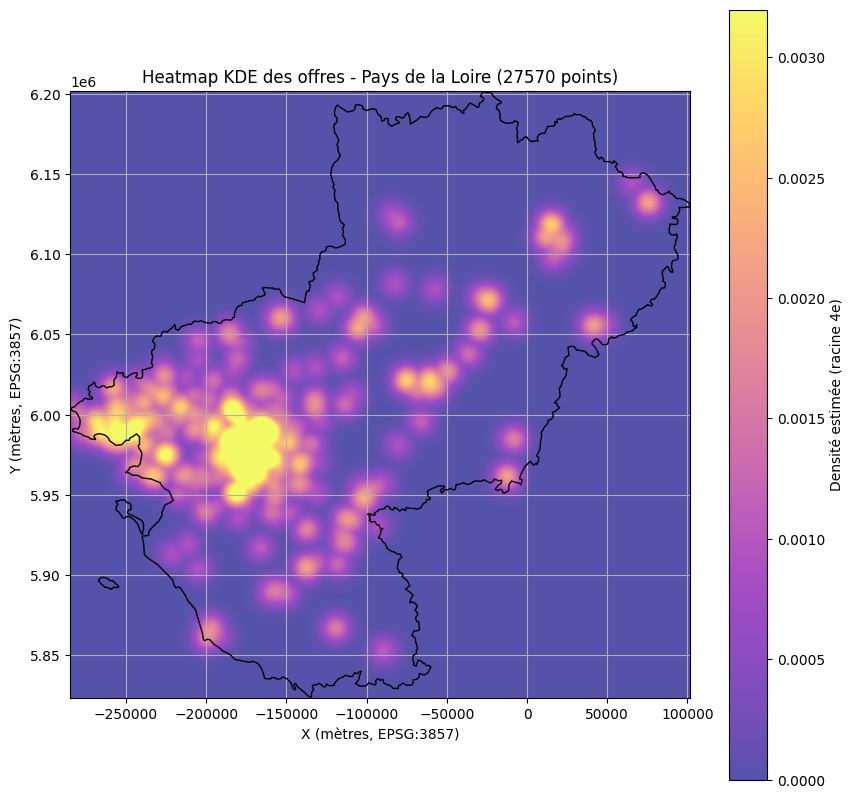

Traitement de la région : Bretagne (53)


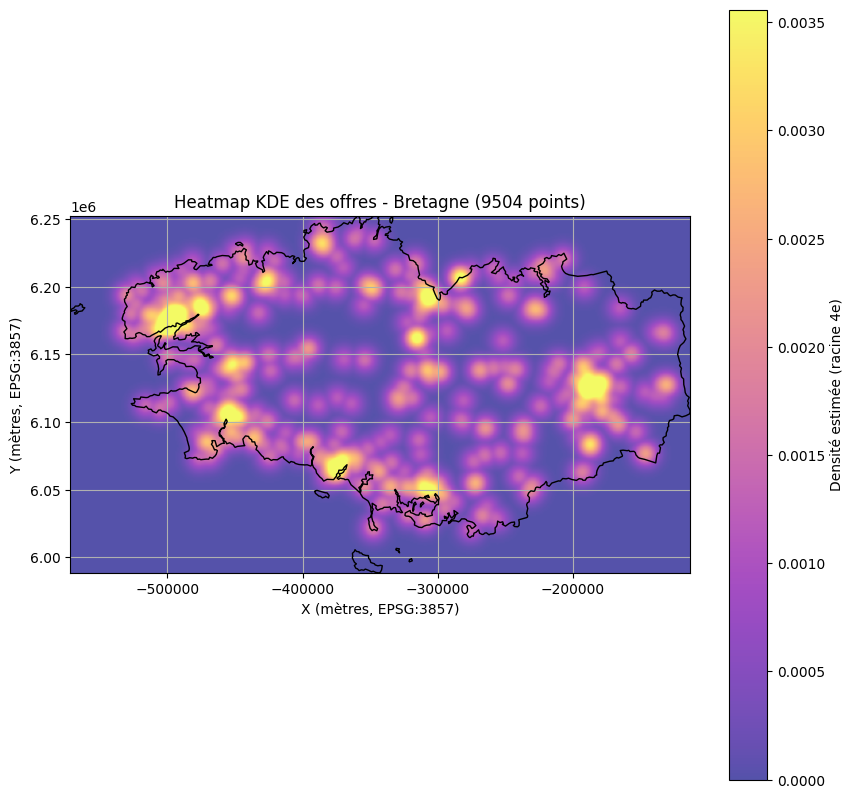

Traitement de la région : Nouvelle-Aquitaine (75)


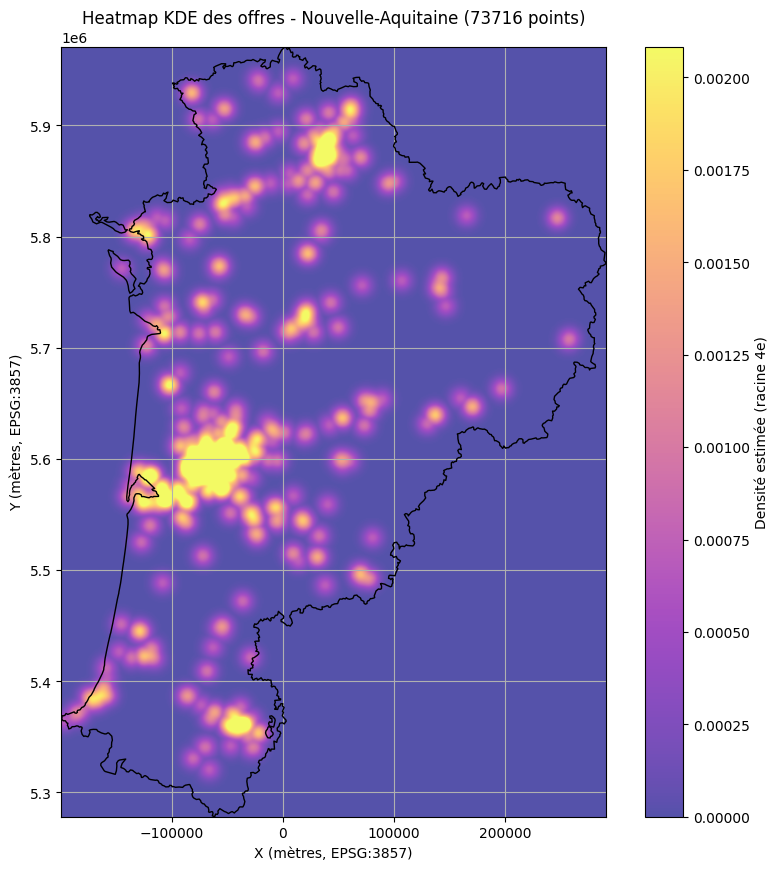

Traitement de la région : Occitanie (76)


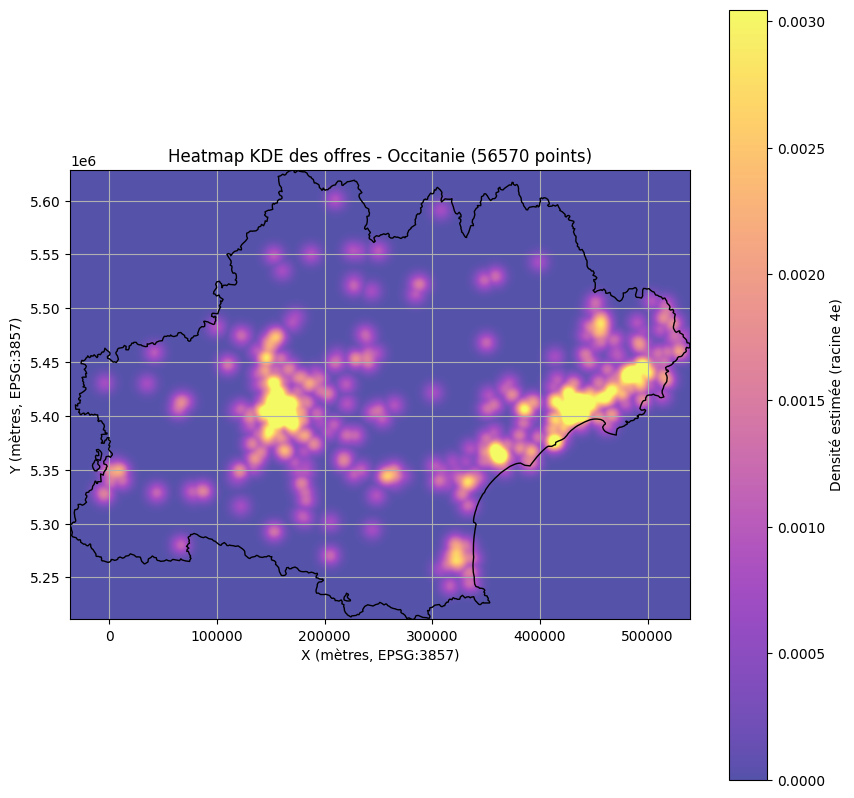

Traitement de la région : Auvergne-Rhône-Alpes (84)


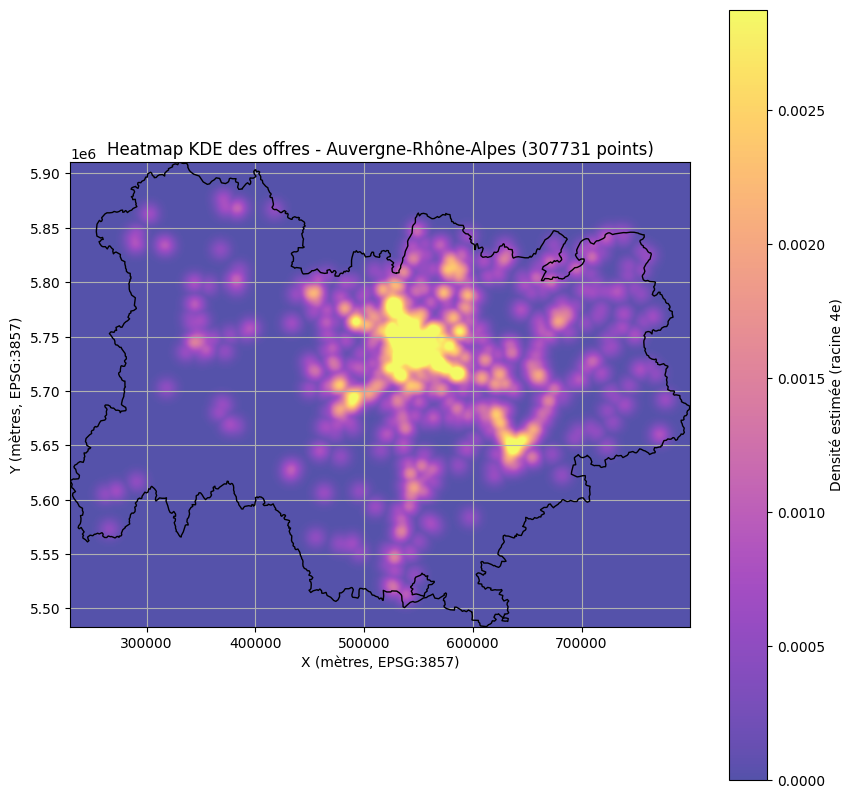

Traitement de la région : Provence-Alpes-Côte d'Azur (93)


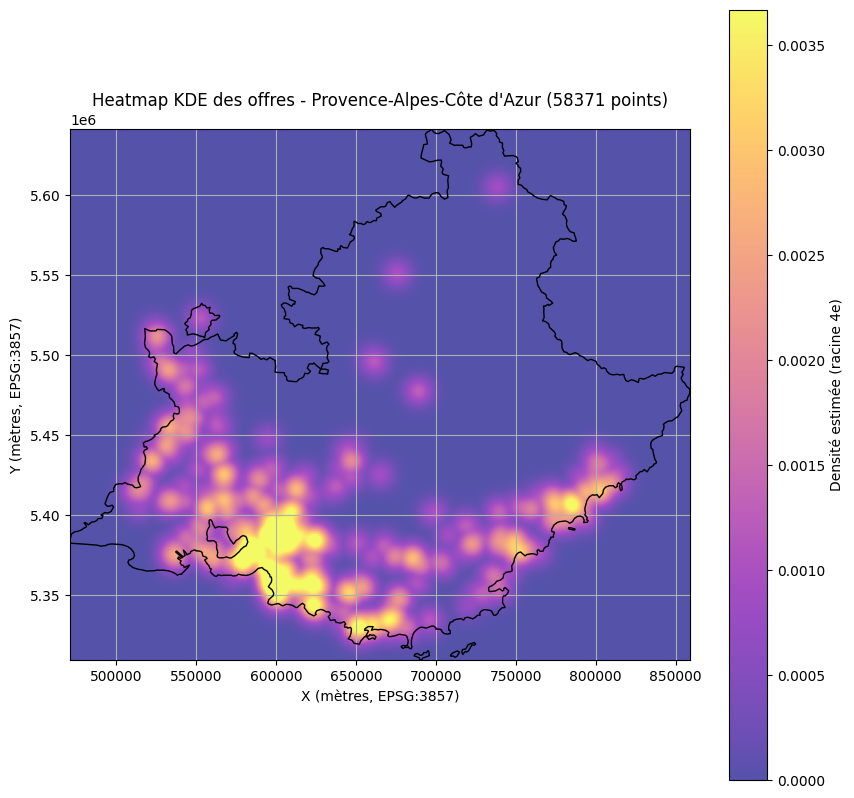

Traitement de la région : Corse (94)


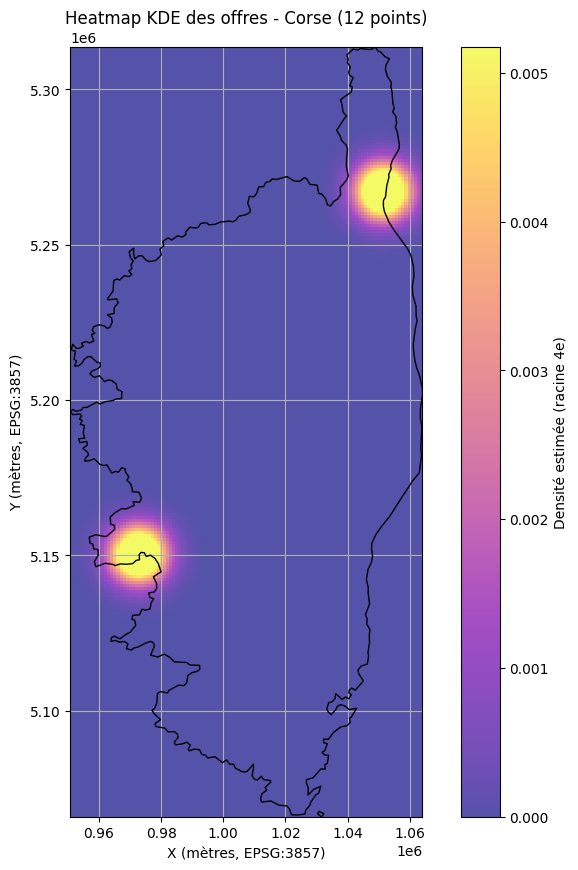

In [58]:
# Charger les données d'offres (ton GeoDataFrame)
# gdf_offres = ...

# Charger les régions françaises (métropolitaines + DOM-TOM)
gdf_regions = gpd.read_file("https://france-geojson.gregoiredavid.fr/repo/regions.geojson")

# Filtrer uniquement les régions métropolitaines (hors DOM-TOM)
# Voici la liste officielle des codes INSEE des régions métropolitaines (13 régions)
codes_metropole = ['11', '24', '27', '28', '32', '44', '52', '53', '75', '76', '84', '93', '94']
gdf_regions = gdf_regions[gdf_regions['code'].isin(codes_metropole)].copy()

# Assurer la projection EPSG:3857 pour tout le monde (projection métrique)
gdf_regions = gdf_regions.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

# Paramètres KDE
grid_size = 1000       # résolution de la grille
bandwidth = 3000      # largeur de bande KDE

# Fonction pour générer la heatmap pour une région donnée
def plot_kde_region(region_gdf, region_name) :
    # Filtrer les points dans la région
    mask = gdf_offres.geometry.within(region_gdf.geometry.iloc[0])
    gdf_region_points = gdf_offres[mask].copy()

    if len(gdf_region_points) == 0:
        print(f"Aucun point dans la région {region_name}, skip")
        return

    # Coordonnées des points
    coords = np.array([(pt.x, pt.y) for pt in gdf_region_points.geometry])

    # Définir la grille sur les bounds de la région
    x_min, y_min, x_max, y_max = region_gdf.total_bounds
    x_grid = np.arange(x_min, x_max, grid_size)
    y_grid = np.arange(y_min, y_max, grid_size)
    xv, yv = np.meshgrid(x_grid, y_grid)
    grid_coords = np.vstack([xv.ravel(), yv.ravel()]).T

    # KDE
    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian', metric='euclidean')
    kde.fit(coords)

    # Découpage pour parallélisation
    n_jobs = -1
    chunk_size = int(len(grid_coords) / (4 * os.cpu_count())) or 1

    def process_chunk(chunk):
        return kde.score_samples(chunk)

    chunks = [grid_coords[i:i + chunk_size] for i in range(0, len(grid_coords), chunk_size)]
    log_densities_chunks = Parallel(n_jobs=n_jobs)(delayed(process_chunk)(chunk) for chunk in chunks)

    log_density = np.concatenate(log_densities_chunks)
    density = np.exp(log_density).reshape(len(y_grid), len(x_grid))

    # Transformation racine 4e pour la couleur
    density_root = density ** 0.25

    vmin = np.percentile(density_root, 5)
    vmax = np.percentile(density_root, 99)

    # Affichage
    fig, ax = plt.subplots(figsize=(10, 10))
    heatmap = ax.imshow(
        density_root,
        extent=(x_min, x_max, y_min, y_max),
        origin='lower',
        cmap='plasma',
        alpha=0.7,
        vmin=vmin,
        vmax=vmax
    )

    # Contours de la région
    region_gdf.boundary.plot(ax=ax, color='black', linewidth=1)

    plt.colorbar(heatmap, ax=ax, label="Densité estimée (racine 4e)")
    ax.set_title(f"Heatmap KDE des offres - {region_name} ({len(gdf_region_points)} points)")
    ax.set_xlabel("X (mètres, EPSG:3857)")
    ax.set_ylabel("Y (mètres, EPSG:3857)")
    plt.grid(True)
    plt.show()

# Boucle sur toutes les régions métropolitaines
for idx, region in gdf_regions.iterrows():
    print(f"Traitement de la région : {region['nom']} ({region['code']})")
    plot_kde_region(gdf_regions.loc[[idx]], region['nom'])


Calcul KDE pour Île-de-France (11)
Calcul KDE pour Centre-Val de Loire (24)
Calcul KDE pour Bourgogne-Franche-Comté (27)
Calcul KDE pour Normandie (28)
Calcul KDE pour Hauts-de-France (32)
Calcul KDE pour Grand Est (44)
Calcul KDE pour Pays de la Loire (52)
Calcul KDE pour Bretagne (53)
Calcul KDE pour Nouvelle-Aquitaine (75)
Calcul KDE pour Occitanie (76)
Calcul KDE pour Auvergne-Rhône-Alpes (84)
Calcul KDE pour Provence-Alpes-Côte d'Azur (93)
Calcul KDE pour Corse (94)
Export parquet terminé.


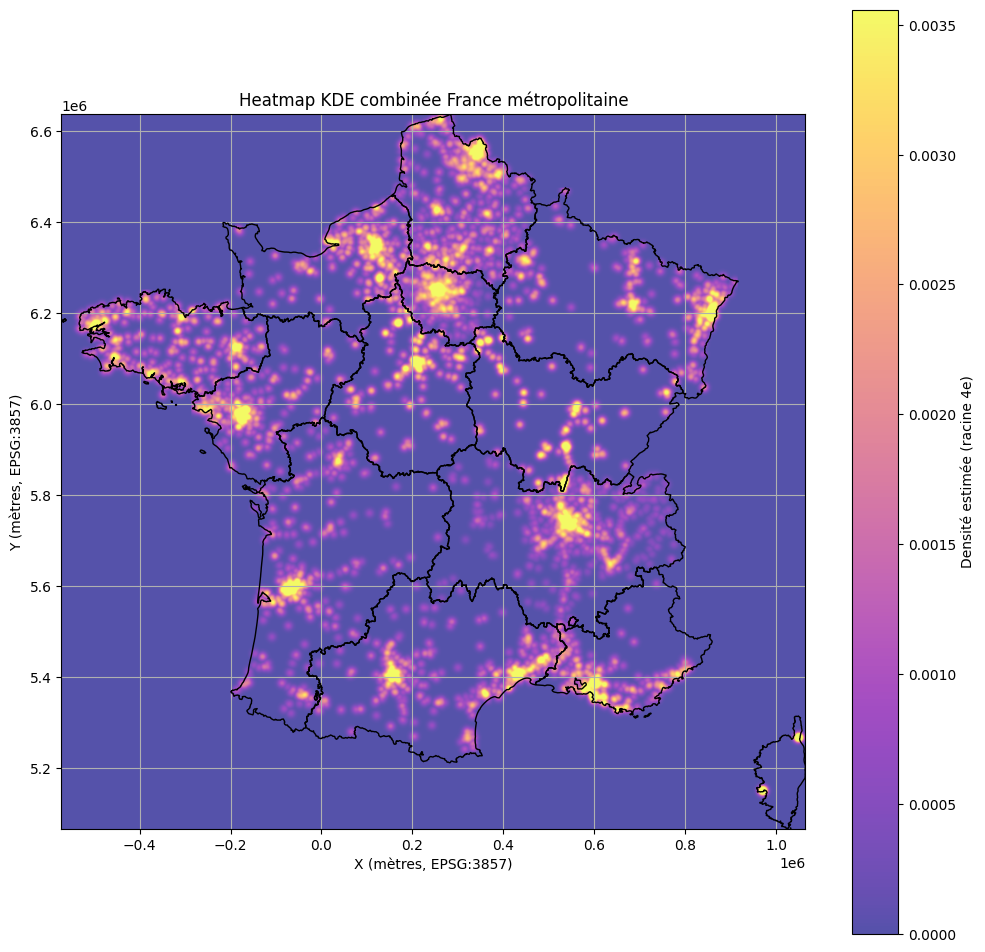

In [57]:
# --- Charger les données (ton GeoDataFrame 'gdf_offres' déjà chargé et en EPSG:3857) ---

# Charger régions métropolitaines
gdf_regions = gpd.read_file("https://france-geojson.gregoiredavid.fr/repo/regions.geojson")
codes_metropole = ['11', '24', '27', '28', '32', '44', '52', '53', '75', '76', '84', '93', '94']
gdf_regions = gdf_regions[gdf_regions['code'].isin(codes_metropole)].copy()
gdf_regions = gdf_regions.to_crs(epsg=3857)

# Paramètres KDE
grid_size = 1000       # résolution en mètres
bandwidth = 3000       # largeur de bande KDE

def compute_kde_region(region_gdf, region_name, gdf_offres):
    # Filtrer points dans la région
    mask = gdf_offres.geometry.within(region_gdf.geometry.iloc[0])
    gdf_region_points = gdf_offres[mask].copy()

    if len(gdf_region_points) == 0:
        print(f"Aucun point dans la région {region_name}, skip")
        return None

    coords = np.array([(pt.x, pt.y) for pt in gdf_region_points.geometry])

    # Grille région
    x_min, y_min, x_max, y_max = region_gdf.total_bounds
    x_grid = np.arange(x_min, x_max + grid_size, grid_size)
    y_grid = np.arange(y_min, y_max + grid_size, grid_size)
    xv, yv = np.meshgrid(x_grid, y_grid)
    grid_coords = np.vstack([xv.ravel(), yv.ravel()]).T

    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian', metric='euclidean')
    kde.fit(coords)

    # Parallélisation
    n_jobs = -1
    chunk_size = int(len(grid_coords) / (4 * os.cpu_count())) or 1

    def process_chunk(chunk):
        return kde.score_samples(chunk)

    chunks = [grid_coords[i:i + chunk_size] for i in range(0, len(grid_coords), chunk_size)]
    log_densities_chunks = Parallel(n_jobs=n_jobs)(delayed(process_chunk)(chunk) for chunk in chunks)

    log_density = np.concatenate(log_densities_chunks)
    density = np.exp(log_density).reshape(len(y_grid), len(x_grid))

    # Retourner dataframe pour assemblage + métadonnées pour affichage
    density_df = pd.DataFrame({
        'x': xv.ravel(),
        'y': yv.ravel(),
        'density': density.ravel(),
        'region': region_name
    })
    return density_df, (x_min, x_max, y_min, y_max)

# Liste pour concaténer
list_density_dfs = []
bounds_list = []

# Boucle sur régions
for idx, region in gdf_regions.iterrows():
    print(f"Calcul KDE pour {region['nom']} ({region['code']})")
    result = compute_kde_region(gdf_regions.loc[[idx]], region['nom'], gdf_offres)
    if result is not None:
        density_df, bounds = result
        list_density_dfs.append(density_df)
        bounds_list.append(bounds)

# Concaténer toutes les données
density_all = pd.concat(list_density_dfs, ignore_index=True)

# Export rapide et efficace
density_all.to_parquet("kde_france_metropole.parquet", index=False, engine="fastparquet")
print("Export parquet terminé.")

# --- Affichage heatmap combinée ---

# Trouver bornes totales
x_min_total = min(b[0] for b in bounds_list)
x_max_total = max(b[1] for b in bounds_list)
y_min_total = min(b[2] for b in bounds_list)
y_max_total = max(b[3] for b in bounds_list)

# Créer grille commune pour affichage
x_grid_total = np.arange(x_min_total, x_max_total + grid_size, grid_size)
y_grid_total = np.arange(y_min_total, y_max_total + grid_size, grid_size)
xv_total, yv_total = np.meshgrid(x_grid_total, y_grid_total)

# Créer matrice vide
density_matrix = np.zeros_like(xv_total, dtype=float)

# Remplir matrice par régions
for region_name in density_all['region'].unique():
    df_region = density_all[density_all['region'] == region_name]
    # Trouver indices correspondants dans la grille globale
    ix = ((df_region['x'] - x_min_total) / grid_size).round().astype(int)
    iy = ((df_region['y'] - y_min_total) / grid_size).round().astype(int)
    density_matrix[iy, ix] += df_region['density'].values

# Transformation couleur
density_root = density_matrix ** 0.25
vmin = np.percentile(density_root[density_root>0], 5)
vmax = np.percentile(density_root[density_root>0], 99)

fig, ax = plt.subplots(figsize=(12,12))
heatmap = ax.imshow(
    density_root,
    extent=(x_min_total, x_max_total, y_min_total, y_max_total),
    origin='lower',
    cmap='plasma',
    alpha=0.7,
    vmin=vmin,
    vmax=vmax
)

# Afficher les contours des régions
gdf_regions.boundary.plot(ax=ax, color='black', linewidth=1)

plt.colorbar(heatmap, ax=ax, label="Densité estimée (racine 4e)")
ax.set_title("Heatmap KDE combinée France métropolitaine")
ax.set_xlabel("X (mètres, EPSG:3857)")
ax.set_ylabel("Y (mètres, EPSG:3857)")
plt.grid(True)
plt.show()